In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('kc_house_data.csv')

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


C:\Users\Arkaprava\AppData\Local\Temp\ipykernel_15568\4141105712.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

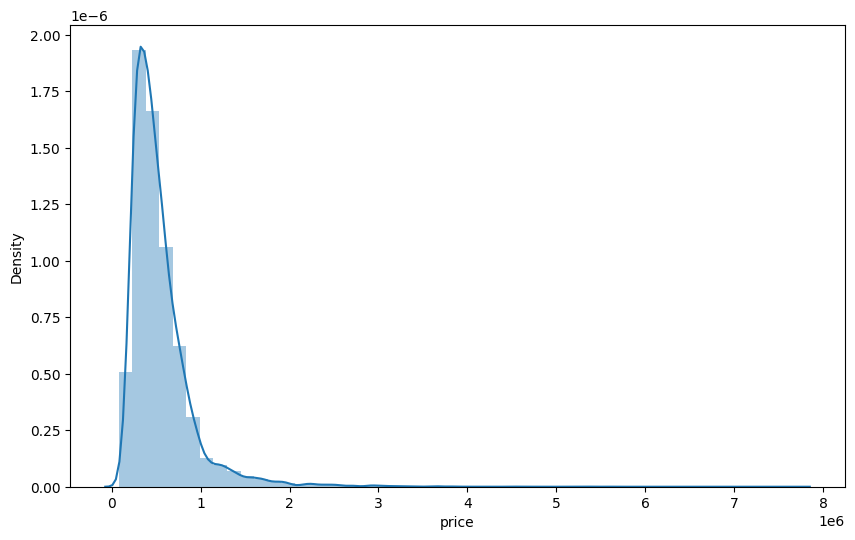

In [4]:
plt.figure(figsize=(10,6))
sns.distplot(df['price'])

In [5]:
df = df.drop('id', axis=1)

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df['year'] = df['date'].apply(lambda date:date.year)
df['month'] = df['date'].apply(lambda date:date.month)

In [8]:
df.drop('date',axis =1,inplace=True)

In [9]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [10]:
X = df.drop('price',axis=1)
y = df['price']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=101)

In [13]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [14]:
scaler = MinMaxScaler()

In [15]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model = Sequential()

In [20]:
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))

model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

In [21]:
model.fit(x=X_train,y=y_train,validation_data=(X_test, y_test),batch_size=128,epochs=400)

Epoch 1/400
119/119 [==============================] - 1s 3ms/step - loss: 430247903232.0000 - val_loss: 418962079744.0000
Epoch 2/400
119/119 [==============================] - 0s 1ms/step - loss: 429814349824.0000 - val_loss: 417430798336.0000
Epoch 3/400
119/119 [==============================] - 0s 1ms/step - loss: 423287652352.0000 - val_loss: 402093441024.0000
Epoch 4/400
119/119 [==============================] - 0s 1ms/step - loss: 387280207872.0000 - val_loss: 338800508928.0000
Epoch 5/400
119/119 [==============================] - 0s 1ms/step - loss: 287858163712.0000 - val_loss: 209783554048.0000
Epoch 6/400
119/119 [==============================] - 0s 1ms/step - loss: 158705827840.0000 - val_loss: 111245926400.0000
Epoch 7/400
119/119 [==============================] - 0s 1ms/step - loss: 105206571008.0000 - val_loss: 97810825216.0000
Epoch 8/400
119/119 [==============================] - 0s 1ms/step - loss: 100163338240.0000 - val_loss: 96350380032.0000
Epoch 9/400
119/11

119/119 [==============================] - 0s 1ms/step - loss: 37481537536.0000 - val_loss: 36566241280.0000
Epoch 69/400
119/119 [==============================] - 0s 1ms/step - loss: 37280772096.0000 - val_loss: 36370210816.0000
Epoch 70/400
119/119 [==============================] - 0s 1ms/step - loss: 37082255360.0000 - val_loss: 36182528000.0000
Epoch 71/400
119/119 [==============================] - 0s 1ms/step - loss: 36856209408.0000 - val_loss: 35989581824.0000
Epoch 72/400
119/119 [==============================] - 0s 1ms/step - loss: 36697006080.0000 - val_loss: 35808739328.0000
Epoch 73/400
119/119 [==============================] - 0s 1ms/step - loss: 36476624896.0000 - val_loss: 35642761216.0000
Epoch 74/400
119/119 [==============================] - 0s 1ms/step - loss: 36300967936.0000 - val_loss: 35514863616.0000
Epoch 75/400
119/119 [==============================] - 0s 1ms/step - loss: 36155330560.0000 - val_loss: 35382726656.0000
Epoch 76/400
119/119 [===============

Epoch 135/400
119/119 [==============================] - 0s 1ms/step - loss: 31080013824.0000 - val_loss: 30830161920.0000
Epoch 136/400
119/119 [==============================] - 0s 1ms/step - loss: 31055458304.0000 - val_loss: 30706919424.0000
Epoch 137/400
119/119 [==============================] - 0s 1ms/step - loss: 31030657024.0000 - val_loss: 30637144064.0000
Epoch 138/400
119/119 [==============================] - 0s 1ms/step - loss: 30938456064.0000 - val_loss: 30808145920.0000
Epoch 139/400
119/119 [==============================] - 0s 1ms/step - loss: 30966448128.0000 - val_loss: 30578987008.0000
Epoch 140/400
119/119 [==============================] - 0s 1ms/step - loss: 30901829632.0000 - val_loss: 30659878912.0000
Epoch 141/400
119/119 [==============================] - 0s 1ms/step - loss: 30881415168.0000 - val_loss: 30536931328.0000
Epoch 142/400
119/119 [==============================] - 0s 1ms/step - loss: 30819846144.0000 - val_loss: 30540599296.0000
Epoch 143/400
11

119/119 [==============================] - 0s 1ms/step - loss: 29270953984.0000 - val_loss: 29017171968.0000
Epoch 202/400
119/119 [==============================] - 0s 1ms/step - loss: 29186086912.0000 - val_loss: 29068888064.0000
Epoch 203/400
119/119 [==============================] - 0s 1ms/step - loss: 29179623424.0000 - val_loss: 28964528128.0000
Epoch 204/400
119/119 [==============================] - 0s 1ms/step - loss: 29140285440.0000 - val_loss: 28898332672.0000
Epoch 205/400
119/119 [==============================] - 0s 1ms/step - loss: 29166764032.0000 - val_loss: 28888211456.0000
Epoch 206/400
119/119 [==============================] - 0s 1ms/step - loss: 29094545408.0000 - val_loss: 29022646272.0000
Epoch 207/400
119/119 [==============================] - 0s 1ms/step - loss: 29097900032.0000 - val_loss: 28898889728.0000
Epoch 208/400
119/119 [==============================] - 0s 1ms/step - loss: 29061058560.0000 - val_loss: 28830380032.0000
Epoch 209/400
119/119 [=======

119/119 [==============================] - 0s 2ms/step - loss: 27971878912.0000 - val_loss: 27984848896.0000
Epoch 268/400
119/119 [==============================] - 0s 2ms/step - loss: 27956381696.0000 - val_loss: 27907899392.0000
Epoch 269/400
119/119 [==============================] - 0s 2ms/step - loss: 27969001472.0000 - val_loss: 27867897856.0000
Epoch 270/400
119/119 [==============================] - 0s 2ms/step - loss: 27956430848.0000 - val_loss: 27858890752.0000
Epoch 271/400
119/119 [==============================] - 0s 2ms/step - loss: 27915540480.0000 - val_loss: 27873597440.0000
Epoch 272/400
119/119 [==============================] - 0s 2ms/step - loss: 27918589952.0000 - val_loss: 27884677120.0000
Epoch 273/400
119/119 [==============================] - 0s 2ms/step - loss: 27903537152.0000 - val_loss: 27904825344.0000
Epoch 274/400
119/119 [==============================] - 0s 2ms/step - loss: 27877703680.0000 - val_loss: 27823013888.0000
Epoch 275/400
119/119 [=======

119/119 [==============================] - 0s 2ms/step - loss: 27160698880.0000 - val_loss: 27156793344.0000
Epoch 334/400
119/119 [==============================] - 0s 2ms/step - loss: 27110975488.0000 - val_loss: 27180572672.0000
Epoch 335/400
119/119 [==============================] - 0s 2ms/step - loss: 27094351872.0000 - val_loss: 27199250432.0000
Epoch 336/400
119/119 [==============================] - 0s 2ms/step - loss: 27096711168.0000 - val_loss: 27162294272.0000
Epoch 337/400
119/119 [==============================] - 0s 2ms/step - loss: 27062210560.0000 - val_loss: 27124160512.0000
Epoch 338/400
119/119 [==============================] - 0s 2ms/step - loss: 27073345536.0000 - val_loss: 27113023488.0000
Epoch 339/400
119/119 [==============================] - 0s 2ms/step - loss: 27046821888.0000 - val_loss: 27394609152.0000
Epoch 340/400
119/119 [==============================] - 0s 2ms/step - loss: 27051042816.0000 - val_loss: 27224862720.0000
Epoch 341/400
119/119 [=======

119/119 [==============================] - 0s 2ms/step - loss: 26453411840.0000 - val_loss: 26429730816.0000
Epoch 400/400
119/119 [==============================] - 0s 2ms/step - loss: 26404276224.0000 - val_loss: 26497427456.0000


In [24]:
losses = pd.DataFrame(model.history.history)

<Axes: >

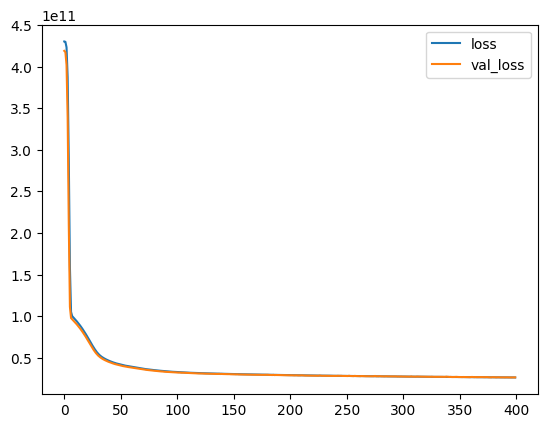

In [25]:
losses.plot()